In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp

# make plots render inline
%matplotlib inline

# reproducibility
RNG = np.random.default_rng(42)

print("Loading Olist data from local data/ folder...")
base = "data"
orders = pd.read_csv(f"{base}/olist_orders_dataset.csv")
order_items = pd.read_csv(f"{base}/olist_order_items_dataset.csv")
order_payments = pd.read_csv(f"{base}/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(f"{base}/olist_order_reviews_dataset.csv")
products = pd.read_csv(f"{base}/olist_products_dataset.csv")
sellers = pd.read_csv(f"{base}/olist_sellers_dataset.csv")
category_translation = pd.read_csv(f"{base}/product_category_name_translation.csv")
print(f"  orders: {orders.shape}, reviews: {order_reviews.shape}")

Loading Olist data from local data/ folder...
  orders: (99441, 8), reviews: (99224, 7)


In [8]:
def engineer_features(orders_df, order_items_df, order_payments_df,
                      order_reviews_df, products_df, sellers_df, category_translation_df):
    """build the 14 hw2 features from raw olist tables"""

    df = orders_df.copy()
    reviews_agg = order_reviews_df.groupby("order_id", as_index=False)["review_score"].mean()
    df = df.merge(reviews_agg, on="order_id", how="left")
    df = df[df["review_score"].notna()].copy()
    df["is_positive_review"] = (df["review_score"] >= 4).astype(int)

    items_agg = order_items_df.groupby("order_id", as_index=False).agg(
        number_of_items=("order_item_id", "count"),
        total_order_value=("price", "sum"),
        avg_product_price=("price", "mean"),
        max_product_price=("price", "max"),
        min_product_price=("price", "min"),
        total_freight_value=("freight_value", "sum"),
        avg_freight_value=("freight_value", "mean"),
        max_freight_value=("freight_value", "max"),
    )
    df = df.merge(items_agg, on="order_id", how="left")

    for c in ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]:
        df[c] = pd.to_datetime(df[c], errors="coerce")
    df["delivery_days"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days
    df["delivery_vs_estimated"] = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.days

    payment_agg = order_payments_df.groupby("order_id")["payment_type"].agg(lambda x: x.mode()[0]).reset_index()
    df = df.merge(payment_agg, on="order_id", how="left")

    items_sellers = order_items_df[["order_id", "seller_id"]].merge(
        sellers_df[["seller_id", "seller_state"]], on="seller_id", how="left"
    )
    seller_state_agg = items_sellers.groupby("order_id")["seller_state"].agg(lambda x: x.mode()[0]).reset_index()
    df = df.merge(seller_state_agg, on="order_id", how="left")

    def safe_mode(s):
        s = s.dropna()
        return np.nan if s.empty else s.mode().iloc[0]

    items_products = order_items_df[["order_id", "product_id"]].merge(
        products_df[["product_id", "product_category_name"]], on="product_id", how="left"
    ).merge(category_translation_df, on="product_category_name", how="left")
    items_products["product_category"] = items_products["product_category_name_english"].fillna(
        items_products["product_category_name"]
    )
    product_cat_agg = items_products.groupby("order_id")["product_category"].agg(safe_mode).reset_index()
    df = df.merge(product_cat_agg, on="order_id", how="left")

    items_photos = order_items_df[["order_id", "product_id"]].merge(
        products_df[["product_id", "product_photos_qty"]], on="product_id", how="left"
    )
    photos_agg = items_photos.groupby("order_id", as_index=False).agg(
        min_product_photos_qty=("product_photos_qty", "min")
    )
    df = df.merge(photos_agg, on="order_id", how="left")

    return df


# run feature engineering
df = engineer_features(orders, order_items, order_payments, order_reviews,
                       products, sellers, category_translation)
print(f"Engineered dataframe: {df.shape}")
print(f"Target distribution: {df['is_positive_review'].value_counts(normalize=True).round(4).to_dict()}")

Engineered dataframe: (98673, 24)
Target distribution: {1: 0.7705, 0: 0.2295}


In [9]:
HW2_FEATURES = [
    "delivery_days", "delivery_vs_estimated", "number_of_items",
    "total_order_value", "avg_product_price", "max_product_price",
    "min_product_price", "total_freight_value", "avg_freight_value",
    "max_freight_value", "product_category", "seller_state",
    "payment_type", "min_product_photos_qty"
]

NUMERIC_FEATURES = [
    "delivery_days", "delivery_vs_estimated", "number_of_items",
    "total_order_value", "avg_product_price", "max_product_price",
    "min_product_price", "total_freight_value", "avg_freight_value",
    "max_freight_value", "min_product_photos_qty"
]
CATEGORICAL_FEATURES = ["product_category", "seller_state", "payment_type"]

y = df["is_positive_review"]
X = df[HW2_FEATURES]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.4f}")
print(f"Test positive rate:  {y_test.mean():.4f}")

Train: (78938, 14), Test: (19735, 14)
Train positive rate: 0.7705
Test positive rate:  0.7705


In [10]:
import time

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), NUMERIC_FEATURES),
    ("cat", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), CATEGORICAL_FEATURES),
])

hw2_rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100, max_depth=30, random_state=42, n_jobs=-1
    )),
])

start = time.time()
hw2_rf.fit(X_train, y_train)
train_time = time.time() - start

# quick check on test set - should match what we've seen before (0.81 accuracy, 0.72 AUC)
y_pred_test = hw2_rf.predict(X_test)
y_proba_test = hw2_rf.predict_proba(X_test)[:, 1]

print(f"Training time: {train_time:.1f}s")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Test AUC:      {roc_auc_score(y_test, y_proba_test):.4f}")

Training time: 12.2s
Test accuracy: 0.8089
Test AUC:      0.7248


In [11]:
# simulate 6 months of production data (3000 per month = 18000 total)
# months 1-3: stable, just 5% noise on numerics, labels unchanged
# months 4-6: progressive drift on delivery_days, freight, electronics share, and 5% label flips

N_PER_MONTH = 3000
NOISE_PCT = 0.05   # ±5% noise on all months

# drift parameters per month (none for months 1-3)
DRIFT = {
    4: {"delivery_add": 2, "freight_mult": 1.15, "electronics_shift_pp": 0.10, "flip_pct": 0.05},
    5: {"delivery_add": 4, "freight_mult": 1.30, "electronics_shift_pp": 0.15, "flip_pct": 0.05},
    6: {"delivery_add": 6, "freight_mult": 1.50, "electronics_shift_pp": 0.20, "flip_pct": 0.05},
}

FREIGHT_COLS = ["total_freight_value", "avg_freight_value", "max_freight_value"]


def simulate_month(base_df, base_y, month, rng):
    """create one month of simulated production data"""
    # sample 3000 rows with replacement
    idx = rng.choice(len(base_df), size=N_PER_MONTH, replace=True)
    X_month = base_df.iloc[idx].copy().reset_index(drop=True)
    y_month = base_y.iloc[idx].reset_index(drop=True).copy()

    # apply ±5% noise to all numeric features (every month, including stable ones)
    for col in NUMERIC_FEATURES:
        vals = X_month[col].values.astype(float)
        noise_factor = 1.0 + rng.uniform(-NOISE_PCT, NOISE_PCT, size=len(vals))
        X_month[col] = vals * noise_factor

    # apply drift if this is a drift month
    if month in DRIFT:
        d = DRIFT[month]

        # delivery_days: add fixed amount to mean
        X_month["delivery_days"] = X_month["delivery_days"] + d["delivery_add"]

        # freight cols: multiply
        for col in FREIGHT_COLS:
            X_month[col] = X_month[col] * d["freight_mult"]

        # shift product_category: take X% of non-electronics rows and make them electronics
        not_electronics = X_month["product_category"] != "electronics"
        n_to_shift = int(len(X_month) * d["electronics_shift_pp"])
        if not_electronics.sum() >= n_to_shift:
            shift_idx = rng.choice(
                X_month.index[not_electronics].values,
                size=n_to_shift, replace=False
            )
            X_month.loc[shift_idx, "product_category"] = "electronics"

        # flip 5% of positive labels to negative
        pos_idx = y_month.index[y_month == 1].values
        n_flip = int(len(y_month) * d["flip_pct"])
        if len(pos_idx) >= n_flip:
            flip_idx = rng.choice(pos_idx, size=n_flip, replace=False)
            y_month.loc[flip_idx] = 0

    X_month["month"] = month
    return X_month, y_month


# build all 6 months
month_dfs = []
month_ys = []

for m in range(1, 7):
    Xm, ym = simulate_month(X_test, y_test, m, RNG)
    month_dfs.append(Xm)
    month_ys.append(ym)
    elec_pct = (Xm["product_category"] == "electronics").mean()
    pos_pct = ym.mean()
    print(f"Month {m}: {len(Xm)} rows, delivery_days mean={Xm['delivery_days'].mean():.1f}, "
          f"freight mean={Xm['total_freight_value'].mean():.1f}, "
          f"electronics={elec_pct:.1%}, positive rate={pos_pct:.1%}")

production_X = pd.concat(month_dfs, ignore_index=True)
production_y = pd.concat(month_ys, ignore_index=True)

print(f"\nTotal production data: {production_X.shape}")

Month 1: 3000 rows, delivery_days mean=12.1, freight mean=23.3, electronics=3.0%, positive rate=77.1%
Month 2: 3000 rows, delivery_days mean=12.2, freight mean=23.3, electronics=2.7%, positive rate=77.6%
Month 3: 3000 rows, delivery_days mean=12.1, freight mean=23.5, electronics=2.2%, positive rate=77.3%
Month 4: 3000 rows, delivery_days mean=13.8, freight mean=26.8, electronics=12.3%, positive rate=72.0%
Month 5: 3000 rows, delivery_days mean=16.5, freight mean=29.9, electronics=17.6%, positive rate=71.2%
Month 6: 3000 rows, delivery_days mean=18.2, freight mean=34.9, electronics=22.4%, positive rate=71.0%

Total production data: (18000, 15)


In [14]:
 # psi calculation with outlier-clipped equal-width bins
# we clip the reference data at the 99th percentile before building bin edges
# this gives meaningful PSI when the distribution has a long tail
# (a single outlier of 1794 reai would otherwise make 99.8% of data fall in bin 1)

REF_FEATURES_FOR_DRIFT = ["delivery_days", "total_freight_value", "total_order_value"]
N_BINS = 10
EPSILON = 0.0001  # tiny constant to avoid log(0)
CLIP_QUANTILE = 0.99  # cap at 99th percentile to handle long tails


def calculate_psi(reference, current, n_bins=10, epsilon=0.0001, clip_quantile=0.99):
    """calculate PSI between reference and current distributions.
    uses 10 equal-width bins on clipped data to handle long-tailed distributions."""
    ref = pd.Series(reference).dropna().values
    cur = pd.Series(current).dropna().values

    # clip the ref range at the 99th percentile to prevent single outliers
    # from dominating the bin edges
    clip_max = np.quantile(ref, clip_quantile)
    min_val = ref.min()

    # equal-width bin edges over the clipped range
    edges = np.linspace(min_val, clip_max, n_bins + 1)
    # extend outer edges to catch anything beyond the clipped range
    edges[0] = -np.inf
    edges[-1] = np.inf

    ref_counts, _ = np.histogram(ref, bins=edges)
    cur_counts, _ = np.histogram(cur, bins=edges)

    ref_pct = ref_counts / ref_counts.sum() + epsilon
    cur_pct = cur_counts / cur_counts.sum() + epsilon

    psi = np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct))
    return psi


# recompute psi with the clipped-bin approach
psi_results = {}

for feature in REF_FEATURES_FOR_DRIFT:
    ref_values = X_train[feature]
    psi_results[feature] = []
    for m in range(1, 7):
        month_data = production_X[production_X["month"] == m][feature]
        psi_val = calculate_psi(ref_values, month_data, n_bins=N_BINS,
                                epsilon=EPSILON, clip_quantile=CLIP_QUANTILE)
        psi_results[feature].append(psi_val)

psi_df = pd.DataFrame(psi_results, index=[f"Month {m}" for m in range(1, 7)]).T
psi_df.columns.name = "Feature"
print("PSI: feature x month (vs training reference)")
print("Using 10 equal-width bins over the 99th-percentile-clipped reference range\n")
print(psi_df.round(4))


def psi_label(psi):
    if psi < 0.1:
        return "GREEN (stable)"
    elif psi < 0.2:
        return "YELLOW (moderate)"
    else:
        return "RED (significant)"


print("\nInterpretation:\n")
for feature in REF_FEATURES_FOR_DRIFT:
    print(f"  {feature}:")
    for m, psi in enumerate(psi_results[feature], 1):
        print(f"    Month {m}: {psi:.4f} - {psi_label(psi)}")

PSI: feature x month (vs training reference)
Using 10 equal-width bins over the 99th-percentile-clipped reference range

Feature              Month 1  Month 2  Month 3  Month 4  Month 5  Month 6
delivery_days         0.0159   0.0108   0.0190   0.1033   1.1867   1.5492
total_freight_value   0.0024   0.0057   0.0047   0.0571   0.2737   0.9985
total_order_value     0.0044   0.0042   0.0090   0.0024   0.0026   0.0062

Interpretation:

  delivery_days:
    Month 1: 0.0159 - GREEN (stable)
    Month 2: 0.0108 - GREEN (stable)
    Month 3: 0.0190 - GREEN (stable)
    Month 4: 0.1033 - YELLOW (moderate)
    Month 5: 1.1867 - RED (significant)
    Month 6: 1.5492 - RED (significant)
  total_freight_value:
    Month 1: 0.0024 - GREEN (stable)
    Month 2: 0.0057 - GREEN (stable)
    Month 3: 0.0047 - GREEN (stable)
    Month 4: 0.0571 - GREEN (stable)
    Month 5: 0.2737 - RED (significant)
    Month 6: 0.9985 - RED (significant)
  total_order_value:
    Month 1: 0.0044 - GREEN (stable)
    Mont

In [15]:
# KS test: scipy.stats.ks_2samp
# compares two distributions directly (no binning), returns statistic and p-value
# p < 0.05 means the distributions are significantly different

ks_results = {"feature": [], "month": [], "ks_stat": [], "p_value": [], "significant": []}

for feature in REF_FEATURES_FOR_DRIFT:
    ref_values = X_train[feature].dropna().values
    for m in range(1, 7):
        month_data = production_X[production_X["month"] == m][feature].dropna().values
        ks_stat, p_val = ks_2samp(ref_values, month_data)
        ks_results["feature"].append(feature)
        ks_results["month"].append(m)
        ks_results["ks_stat"].append(ks_stat)
        ks_results["p_value"].append(p_val)
        ks_results["significant"].append(p_val < 0.05)

ks_df = pd.DataFrame(ks_results)
print("KS test results (reference = X_train)\n")
print(ks_df.round(6).to_string(index=False))

# highlight significant drift
print("\nSignificant drift (p < 0.05):\n")
sig = ks_df[ks_df["significant"]]
if len(sig) == 0:
    print("  None detected")
else:
    for _, row in sig.iterrows():
        print(f"  {row['feature']:25s} Month {int(row['month'])}: "
              f"KS stat={row['ks_stat']:.4f}, p={row['p_value']:.6f}")

KS test results (reference = X_train)

            feature  month  ks_stat  p_value  significant
      delivery_days      1 0.042435 0.000080         True
      delivery_days      2 0.040965 0.000158         True
      delivery_days      3 0.061286 0.000000         True
      delivery_days      4 0.171100 0.000000         True
      delivery_days      5 0.306203 0.000000         True
      delivery_days      6 0.434089 0.000000         True
total_freight_value      1 0.032325 0.004847         True
total_freight_value      2 0.029422 0.013624         True
total_freight_value      3 0.034912 0.001791         True
total_freight_value      4 0.174461 0.000000         True
total_freight_value      5 0.315884 0.000000         True
total_freight_value      6 0.430188 0.000000         True
  total_order_value      1 0.040774 0.000139         True
  total_order_value      2 0.020888 0.161098        False
  total_order_value      3 0.031159 0.007453         True
  total_order_value      4 0.0180

In [16]:
# part 5c: performance monitoring
# run hw2 rf on all 18000 production records, compute metrics per month

# get predictions on the production data - use the feature columns only (drop month)
feature_cols = HW2_FEATURES
production_X_features = production_X[feature_cols]

y_pred_prod = hw2_rf.predict(production_X_features)
y_proba_prod = hw2_rf.predict_proba(production_X_features)[:, 1]

# build a results dataframe with month, predictions, actuals
monthly_perf = pd.DataFrame({
    "month": production_X["month"].values,
    "y_true": production_y.values,
    "y_pred": y_pred_prod,
    "y_proba": y_proba_prod,
})

# compute metrics per month
rows = []
for m in range(1, 7):
    sub = monthly_perf[monthly_perf["month"] == m]
    rows.append({
        "month": m,
        "accuracy": accuracy_score(sub["y_true"], sub["y_pred"]),
        "f1": f1_score(sub["y_true"], sub["y_pred"]),
        "auc": roc_auc_score(sub["y_true"], sub["y_proba"]),
        "positive_rate": sub["y_true"].mean(),
    })

perf_df = pd.DataFrame(rows).set_index("month")
print("Monthly performance on production data\n")
print(perf_df.round(4))

# report the drop from m1 to m6
m1 = perf_df.loc[1]
m6 = perf_df.loc[6]
print("\nPerformance drop from Month 1 to Month 6:")
for metric in ["accuracy", "f1", "auc"]:
    abs_drop = m1[metric] - m6[metric]
    pct_drop = abs_drop / m1[metric] * 100
    print(f"  {metric}: {m1[metric]:.4f} -> {m6[metric]:.4f}  "
          f"(absolute drop: {abs_drop:.4f}, percentage drop: {pct_drop:.2f}%)")

Monthly performance on production data

       accuracy      f1     auc  positive_rate
month                                         
1        0.8063  0.8858  0.7000         0.7707
2        0.8147  0.8906  0.7356         0.7763
3        0.8123  0.8892  0.7055         0.7730
4        0.7583  0.8527  0.6723         0.7200
5        0.7557  0.8497  0.6723         0.7120
6        0.7503  0.8466  0.6746         0.7103

Performance drop from Month 1 to Month 6:
  accuracy: 0.8063 -> 0.7503  (absolute drop: 0.0560, percentage drop: 6.95%)
  f1: 0.8858 -> 0.8466  (absolute drop: 0.0392, percentage drop: 4.43%)
  auc: 0.7000 -> 0.6746  (absolute drop: 0.0254, percentage drop: 3.62%)


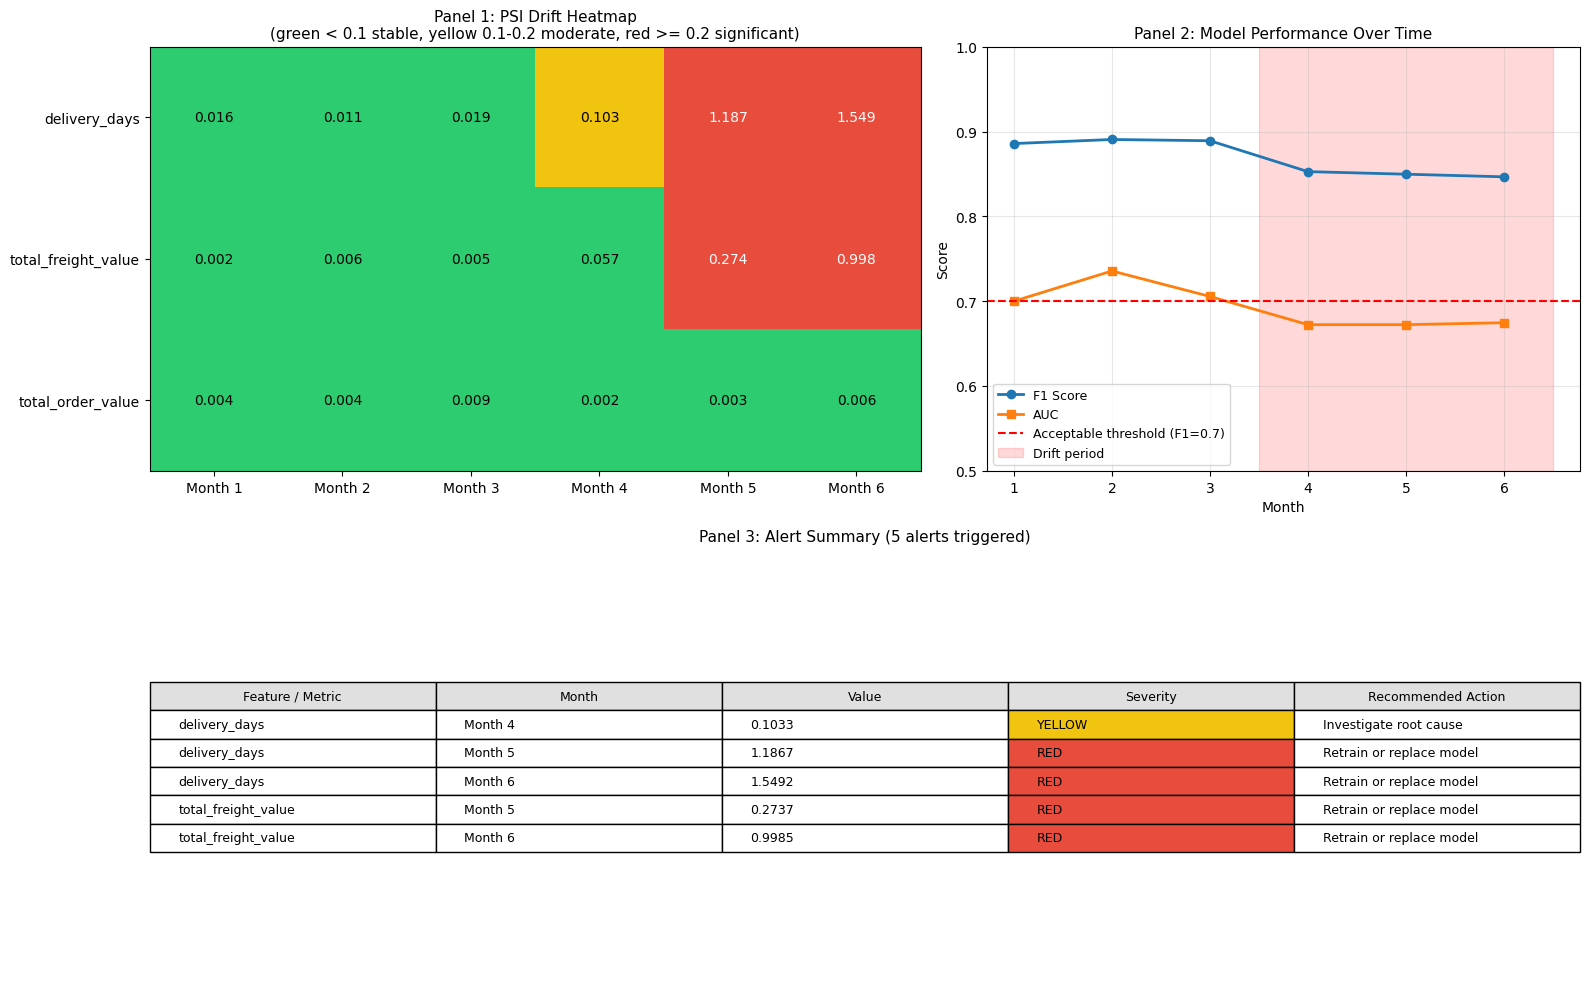


Dashboard saved as part5_monitoring_dashboard.png


In [18]:
# part 5d: 3-panel monitoring dashboard
# panel 1: psi heatmap (features x months, color-coded by severity)
# panel 2: performance trend (F1 and AUC over 6 months, with threshold line)
# panel 3: alert summary table (which features crossed which thresholds when)

from matplotlib.colors import ListedColormap, BoundaryNorm

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1.3, 1])

# ---------- Panel 1: PSI Heatmap ----------
ax1 = fig.add_subplot(gs[0, 0])

# discrete colormap: green < 0.1, yellow 0.1-0.2, red >= 0.2
cmap = ListedColormap(["#2ecc71", "#f1c40f", "#e74c3c"])
norm = BoundaryNorm([0, 0.1, 0.2, float("inf")], cmap.N)

psi_matrix = psi_df.values  # features x months
im = ax1.imshow(psi_matrix, cmap=cmap, norm=norm, aspect="auto")

ax1.set_xticks(range(6))
ax1.set_xticklabels([f"Month {m}" for m in range(1, 7)])
ax1.set_yticks(range(len(psi_df.index)))
ax1.set_yticklabels(psi_df.index)
ax1.set_title("Panel 1: PSI Drift Heatmap\n(green < 0.1 stable, yellow 0.1-0.2 moderate, red >= 0.2 significant)",
              fontsize=11)

# annotate cells with the psi value
for i in range(psi_matrix.shape[0]):
    for j in range(psi_matrix.shape[1]):
        val = psi_matrix[i, j]
        # pick text color for readability
        text_color = "white" if val >= 0.2 else "black"
        ax1.text(j, i, f"{val:.3f}", ha="center", va="center",
                 color=text_color, fontsize=10)

# ---------- Panel 2: Performance Trend ----------
ax2 = fig.add_subplot(gs[0, 1])

months = perf_df.index
ax2.plot(months, perf_df["f1"], marker="o", label="F1 Score", linewidth=2)
ax2.plot(months, perf_df["auc"], marker="s", label="AUC", linewidth=2)

# acceptable threshold line (F1 = 0.70 is a reasonable choice)
F1_THRESHOLD = 0.70
ax2.axhline(y=F1_THRESHOLD, color="red", linestyle="--", linewidth=1.5,
            label=f"Acceptable threshold (F1={F1_THRESHOLD})")

# shade the drift period
ax2.axvspan(3.5, 6.5, alpha=0.15, color="red", label="Drift period")

ax2.set_xlabel("Month")
ax2.set_ylabel("Score")
ax2.set_title("Panel 2: Model Performance Over Time", fontsize=11)
ax2.set_xticks(range(1, 7))
ax2.legend(loc="lower left", fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0.5, 1.0)

# ---------- Panel 3: Alert Summary Table ----------
ax3 = fig.add_subplot(gs[1, :])
ax3.axis("off")

# build alerts: any feature-month combination with PSI >= 0.1
alerts = []
for feature in psi_df.index:
    for m in range(1, 7):
        psi_val = psi_df.loc[feature, f"Month {m}"]
        if psi_val >= 0.1:
            if psi_val >= 0.2:
                action = "Retrain or replace model"
                severity = "RED"
            else:
                action = "Investigate root cause"
                severity = "YELLOW"
            alerts.append([feature, f"Month {m}", f"{psi_val:.4f}", severity, action])

# add performance-based alerts
for m in perf_df.index:
    if perf_df.loc[m, "f1"] < F1_THRESHOLD:
        alerts.append(["F1 score", f"Month {m}", f"{perf_df.loc[m, 'f1']:.4f}",
                       "RED", f"Performance below threshold ({F1_THRESHOLD})"])

if len(alerts) == 0:
    ax3.text(0.5, 0.5, "No alerts: all features stable, performance within threshold",
             ha="center", va="center", fontsize=12)
else:
    table = ax3.table(
        cellText=alerts,
        colLabels=["Feature / Metric", "Month", "Value", "Severity", "Recommended Action"],
        loc="center",
        cellLoc="left",
        colColours=["#e0e0e0"] * 5,
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.4)
    # color the severity column
    for i, alert in enumerate(alerts, start=1):
        sev = alert[3]
        color = "#f1c40f" if sev == "YELLOW" else "#e74c3c"
        table[(i, 3)].set_facecolor(color)

ax3.set_title(f"Panel 3: Alert Summary ({len(alerts)} alerts triggered)",
              fontsize=11, pad=10)

plt.tight_layout()
plt.savefig("part5_monitoring_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nDashboard saved as part5_monitoring_dashboard.png")

## Retraining Recommendation

Yes, the model should be retrained. By Month 5 the PSI for delivery_days (1.19) and total_freight_value (0.27) were both in the red zone, and F1 had dropped from 0.89 to 0.85 while AUC fell below the acceptable threshold of 0.70. The drift is significant and no longer just noise.

For a trigger rule going forward, I would retrain when either of two things happens. First, PSI hits 0.2 or higher on any key feature (delivery_days, freight, or price) for two consecutive months. Second, F1 drops below 0.70 or shows more than a 5% decline from the baseline over a rolling window. A single yellow month (PSI between 0.1 and 0.2) is not enough on its own to retrain, but it should trigger a root cause investigation.

The retrained model should include recent production data from months 4 through 6 with real labels once reviews come in, combined with the original training set so the model does not lose the patterns it already knows. Over time, older training data should be phased out as patterns shift.